# Milestone 3 — EDA & Insight Mobile Legends
Analisis temporal dan 9 visualisasi Plotly interaktif dari `mobilelegends_clean.parquet` hasil Milestone 2. Angka insight dihitung otomatis dari data; notebook paket ini belum dijalankan pada dataset asli pengguna.

## Pertanyaan analisis
1. Bagaimana volume, rating rata-rata, dan proporsi rating rendah berubah per bulan?
2. Kapan ulasan paling sering muncul menurut hari dan jam sumber?
3. Bagaimana rating berbeda antarversi game dengan dukungan sampel memadai?
4. Bagaimana ketersediaan balasan dan waktu balasan berhubungan dengan rating?
5. Seberapa lengkap metadata setelah cleaning?

**Unit analisis:** satu ID ulasan valid unik. Rating rendah = 1–2; sedang = 3; tinggi = 4–5. Proporsi balasan berarti balasan tersedia pada snapshot, bukan probabilitas pengembang selalu membalas.
Analisis observasional tidak membuktikan sebab-akibat atau mewakili semua pemain. Negara/bahasa Indonesia tidak diasumsikan dari nama pengguna. Waktu naive memakai waktu sumber; offset sudah dinormalisasi oleh Milestone 2, sehingga pola jam bukan otomatis WIB. Bulan pertama/terakhir dapat parsial.

DuckDB mengagregasi data di disk dengan batas memori 1 GB. Polars dan Plotly menerima tabel agregat kecil; tidak ada collect seluruh review, NLP, atau random sampling untuk statistik utama. Output HTML mandiri bisa dibuka offline.

In [7]:
from pathlib import Path
import os, json, platform, time
from datetime import datetime, timezone
os.environ['POLARS_MAX_THREADS'] = '2'
import duckdb
import polars as pl
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
CLEAN = Path(os.environ.get('M3_DATA_PATH', str(ROOT / 'data/processed/mobilelegends_clean.parquet')))
WINDOWS_CLEAN = Path(r'C:\Users\ASUS\Documents\Analisis BIGDATA\Tugas 1\tugas1-abd-2026\data\processed\mobilelegends_clean.parquet')
if not CLEAN.is_file() and WINDOWS_CLEAN.is_file():
    CLEAN = WINDOWS_CLEAN
    ROOT = CLEAN.parents[2]
if not CLEAN.is_file():
    raise FileNotFoundError(f'Parquet tidak ditemukan: {CLEAN}. Selesaikan Milestone 2 dan sesuaikan CLEAN.')
OUT = ROOT / 'output/milestone3'
FIGURES = OUT / 'figures'
TABLES = OUT / 'tables'
for p in [OUT, FIGURES, TABLES, OUT / 'duckdb_tmp']: p.mkdir(parents=True, exist_ok=True)
MIN_VERSION_REVIEWS = 100
MIN_MONTH_REVIEWS = 30
SHOW_INLINE = os.environ.get('M3_SHOW_INLINE', '1') == '1'
STARTED = time.perf_counter()
con = duckdb.connect()
con.execute("SET memory_limit='1GB'")
con.execute('SET threads=2')
con.execute("SET temp_directory='" + (OUT / 'duckdb_tmp').as_posix().replace("'", "''") + "'")
path_sql = CLEAN.as_posix().replace("'", "''")
con.execute(f"CREATE VIEW reviews AS SELECT * FROM read_parquet('{path_sql}')")
def query(sql):
    cur = con.execute(sql)
    return pl.DataFrame(cur.fetchall(), schema=[x[0] for x in cur.description], orient='row', infer_schema_length=None)
print('Input:', CLEAN)
print('DuckDB:', duckdb.__version__, '| Polars:', pl.__version__, '| Plotly:', plotly.__version__)

Input: /home/jovyan/work/data/processed/mobilelegends_clean.parquet
DuckDB: 1.5.5 | Polars: 1.44.2 | Plotly: 7.1.0


## 1. Validasi input dan ruang lingkup
Notebook berhenti jika masih ada ID duplikat, rating invalid, content kosong, atau tanggal ulasan null. Data dengan seluruh baris kosong tidak dianalisis. Validasi ini bukan pengganti audit karantina Milestone 2.

In [8]:
required = {'reviewId', 'content', 'score', 'at', 'reviewCreatedVersion', 'replyContent', 'repliedAt',
            'thumbsUpCount', 'content_length', 'reply_delay_hours'}
columns = {x[0] for x in con.execute('DESCRIBE reviews').fetchall()}
if required - columns:
    raise ValueError(f'Kolom hasil Milestone 2 hilang: {sorted(required - columns)}')
validation = query("""
SELECT count(*) AS n, count(*) - count(DISTINCT reviewId) AS duplicate_or_null_ids,
 count(*) FILTER (WHERE trim(reviewId)='') AS blank_ids,
 count(*) FILTER (WHERE score IS NULL OR score NOT BETWEEN 1 AND 5) AS bad_scores,
 count(*) FILTER (WHERE content IS NULL OR trim(content)='') AS bad_content,
 count(*) FILTER (WHERE "at" IS NULL) AS bad_dates
FROM reviews
""").row(0, named=True)
assert validation['n'] > 0, 'Dataset final kosong.'
assert all(v == 0 for k, v in validation.items() if k != 'n'), validation
stats = query("""
SELECT count(*) AS n, min("at") AS start_date, max("at") AS end_date,
 avg(score) AS avg_score,
 count(*) FILTER (WHERE score<=2) AS low_count,
 count(*) FILTER (WHERE replyContent IS NOT NULL) AS reply_count,
 median(content_length) AS median_content_length,
 median(reply_delay_hours) FILTER (WHERE replyContent IS NOT NULL AND reply_delay_hours>=0) AS median_reply_hours,
 count(*) FILTER (WHERE replyContent IS NOT NULL AND reply_delay_hours>=0) AS delay_n
FROM reviews
""").row(0, named=True)
display(pl.DataFrame([stats]))
print('Validasi input lulus.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

n,start_date,end_date,avg_score,low_count,reply_count,median_content_length,median_reply_hours,delay_n
i64,datetime[μs],datetime[μs],f64,i64,i64,f64,f64,i64
10448835,2016-09-24 10:10:08,2026-09-27 07:20:57,3.777315,2833547,138739,23.0,6.861389,116709


Validasi input lulus.


## 2. Tabel agregat temporal, versi, balasan, dan kelengkapan
Periode tanpa ulasan ditambahkan sebagai bulan dengan volume 0, tetapi rata-rata rating tetap null. Proporsi dan rating dihitung dengan denominator masing-masing kelompok. Tidak mengisi bulan kosong dengan rating 0.
Versi dikelompokkan memakai `reviewCreatedVersion`; `appVersion` tidak dianggap kolom ekuivalen secara otomatis. Grafik versi membandingkan maksimal 15 versi berjumlah ulasan terbanyak yang memenuhi ambang 100; versi null dikeluarkan.

In [9]:
monthly = query("""
WITH agg AS (
 SELECT date_trunc('month', "at")::DATE AS month, count(*) AS n, avg(score) AS avg_score,
        count(*) FILTER (WHERE score<=2) AS low_n,
        count(*) FILTER (WHERE replyContent IS NOT NULL) AS replied_n
 FROM reviews GROUP BY 1
), calendar AS (
 SELECT CAST(month AS DATE) AS month FROM generate_series(
    (SELECT min(month) FROM agg), (SELECT max(month) FROM agg), INTERVAL '1 month') t(month)
)
SELECT c.month, coalesce(a.n,0) AS n, a.avg_score,
 100.0*a.low_n/nullif(a.n,0) AS low_pct,
 100.0*a.replied_n/nullif(a.n,0) AS reply_pct
FROM calendar c LEFT JOIN agg a USING(month) ORDER BY 1
""")
ratings = query("""
WITH scores AS (SELECT unnest([1,2,3,4,5]) AS score)
SELECT s.score, count(r.score) AS n, 100.0*count(r.score)/(SELECT count(*) FROM reviews) AS pct
FROM scores s LEFT JOIN reviews r ON r.score=s.score GROUP BY 1 ORDER BY 1
""")
monthly_mix = query("""
SELECT date_trunc('month', "at")::DATE AS month,
 CASE WHEN score<=2 THEN 'Rendah (1–2)' WHEN score=3 THEN 'Sedang (3)' ELSE 'Tinggi (4–5)' END AS category,
 count(*) AS n FROM reviews GROUP BY 1,2 ORDER BY 1,2
""")
weekday_hour = query("""
SELECT CAST(isodow("at") AS INTEGER) AS weekday, CAST(hour("at") AS INTEGER) AS hour,
 count(*) AS n FROM reviews GROUP BY 1,2 ORDER BY 1,2
""")
versions = query(f"""
SELECT reviewCreatedVersion AS version, count(*) AS n, avg(score) AS avg_score,
 100.0*count(*) FILTER (WHERE score<=2)/count(*) AS low_pct
FROM reviews WHERE reviewCreatedVersion IS NOT NULL
GROUP BY 1 HAVING count(*)>={MIN_VERSION_REVIEWS} ORDER BY n DESC, version LIMIT 15
""")
reply_by_score = query("""
SELECT score, count(*) AS n, count(*) FILTER (WHERE replyContent IS NOT NULL) AS reply_n,
 100.0*count(*) FILTER (WHERE replyContent IS NOT NULL)/count(*) AS reply_pct
FROM reviews GROUP BY 1 ORDER BY 1
""")
delay = query("""
SELECT score, count(*) AS n, quantile_cont(reply_delay_hours,0.25) AS q1,
 median(reply_delay_hours) AS median, quantile_cont(reply_delay_hours,0.75) AS q3,
 min(reply_delay_hours) AS minimum, max(reply_delay_hours) AS maximum
FROM reviews WHERE replyContent IS NOT NULL AND reply_delay_hours>=0
GROUP BY 1 ORDER BY 1
""")
missing_columns = ['reviewCreatedVersion','thumbsUpCount','replyContent','repliedAt']
missing = pl.DataFrame([{'column': c,
    'null_n': con.execute(f'SELECT count(*) FROM reviews WHERE "{c}" IS NULL').fetchone()[0]}
    for c in missing_columns]).with_columns((pl.col('null_n')/stats['n']*100).alias('null_pct'))
for name, table in {'monthly':monthly,'ratings':ratings,'monthly_mix':monthly_mix,
    'weekday_hour':weekday_hour,'versions':versions,'reply_by_score':reply_by_score,
    'reply_delay':delay,'missing':missing}.items():
    table.write_csv(TABLES / f'{name}.csv')
assert monthly['n'].sum()==stats['n']==ratings['n'].sum()==weekday_hour['n'].sum()
assert monthly_mix['n'].sum()==stats['n']
display(monthly.head(12))

month,n,avg_score,low_pct,reply_pct
date,i64,f64,f64,f64
2016-09-01,274,3.952555,16.058394,0.0
2016-10-01,1963,4.294447,11.054508,0.0
2016-11-01,4864,4.0625,17.537007,0.0
2016-12-01,10128,4.077705,15.827409,0.0
2017-01-01,10259,3.768106,25.304611,0.0
…,…,…,…,…
2017-04-01,19532,4.424381,8.882859,1.479623
2017-05-01,25702,4.338262,11.065287,0.36184
2017-06-01,42567,4.018841,19.555054,1.235699


## 3. Visualisasi interaktif
Semua grafik menyediakan hover, zoom, dan ekspor gambar melalui toolbar Plotly. HTML masing-masing menyertakan Plotly agar dapat dibuka offline. Dashboard menggabungkan seluruh grafik dengan satu salinan Plotly.
Setiap grafik memakai agregasi seluruh dataset, bukan subset ulasan. Grafik yang tidak memiliki metadata valid menampilkan keterangan kosong; tidak membuat nilai atau insight palsu.

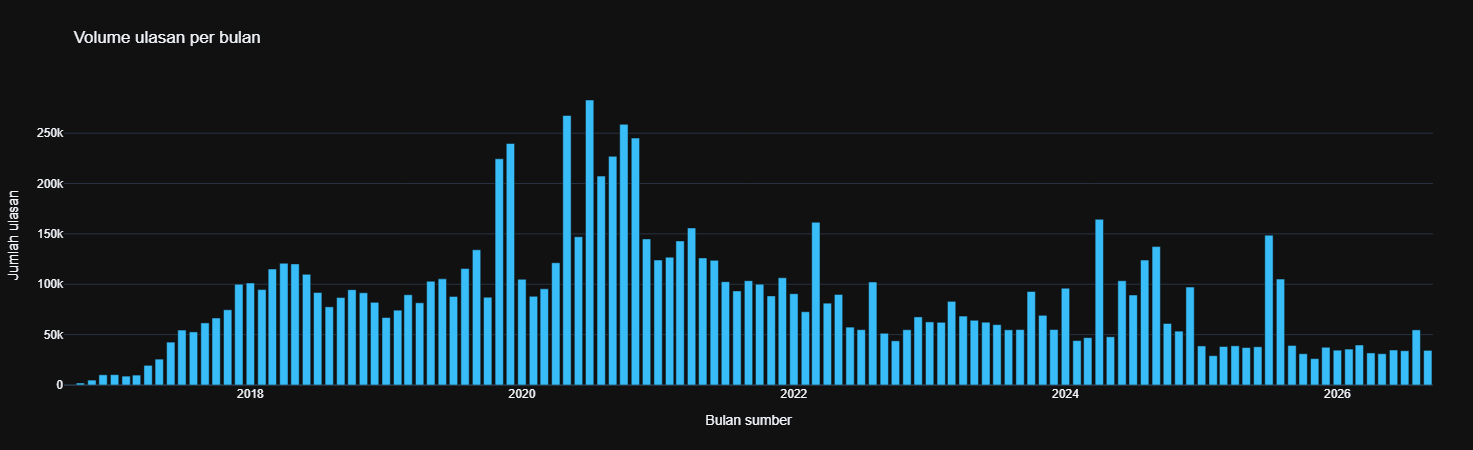

Tersimpan: 01_monthly_volume


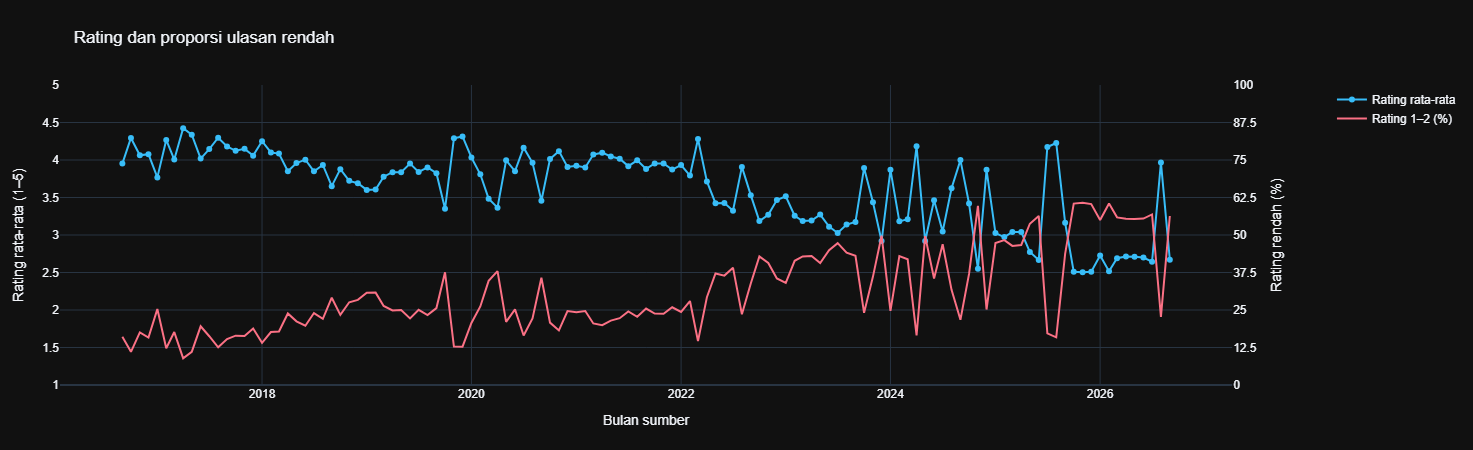

Tersimpan: 02_monthly_rating


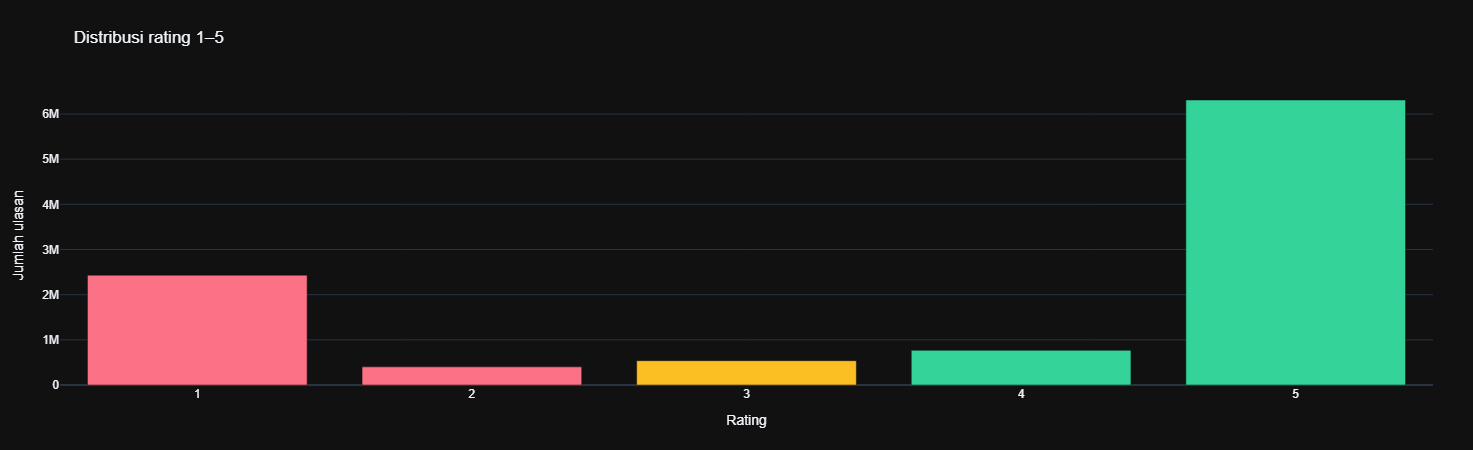

Tersimpan: 03_rating_distribution


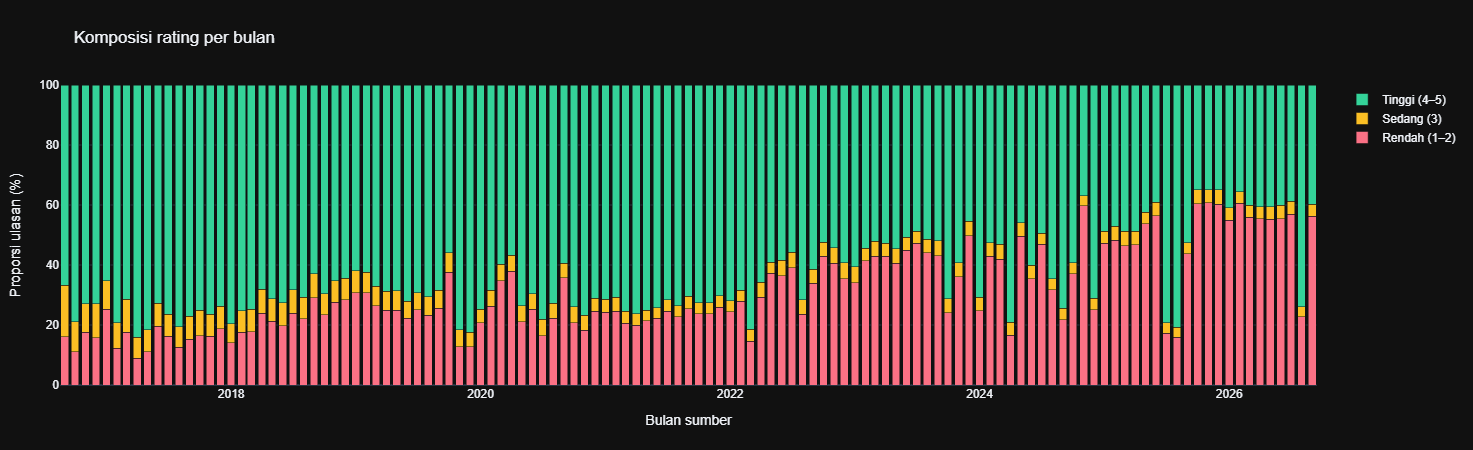

Tersimpan: 04_monthly_mix


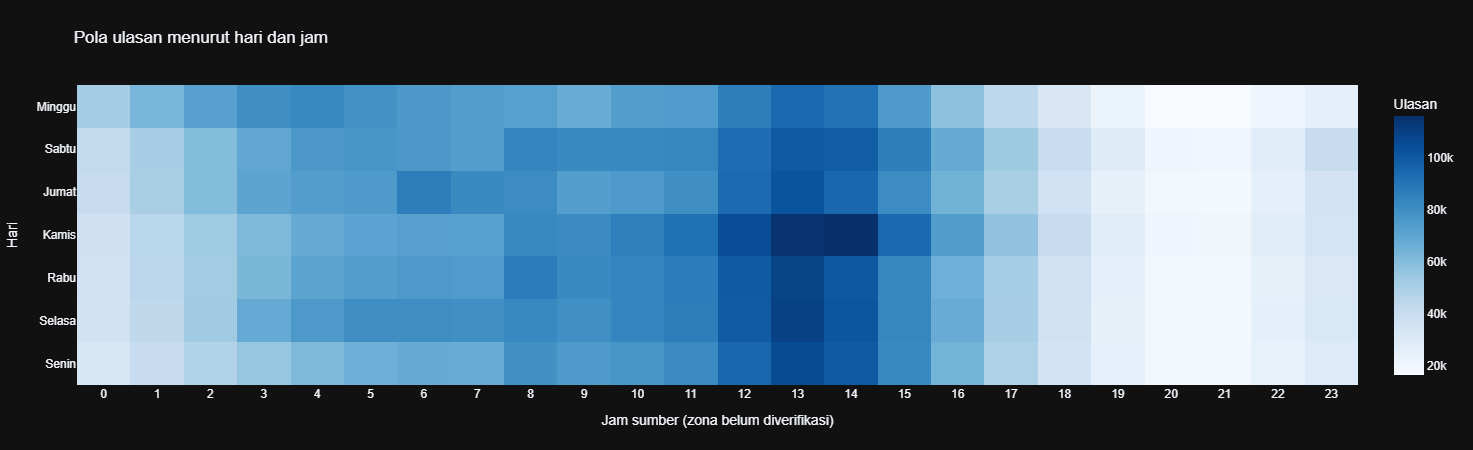

Tersimpan: 05_weekday_hour


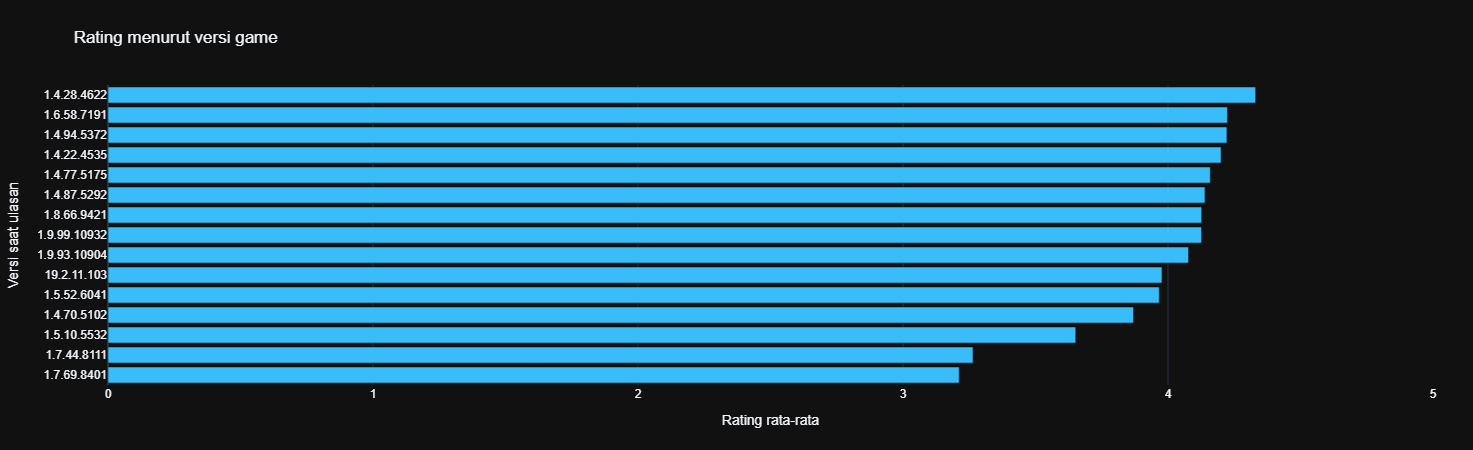

Tersimpan: 06_version_rating


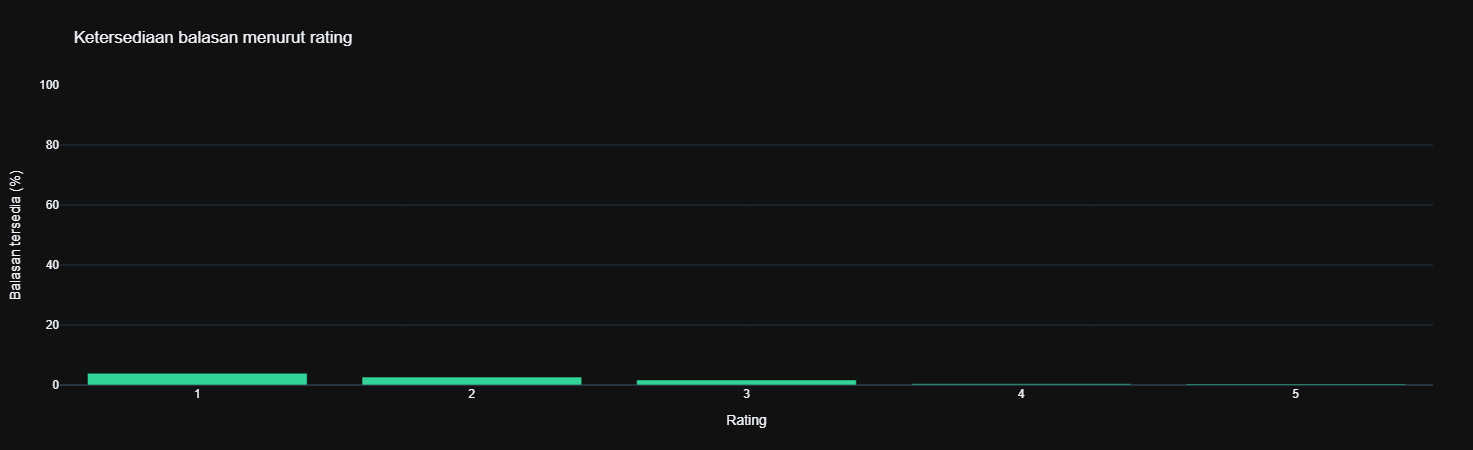

Tersimpan: 07_reply_rate


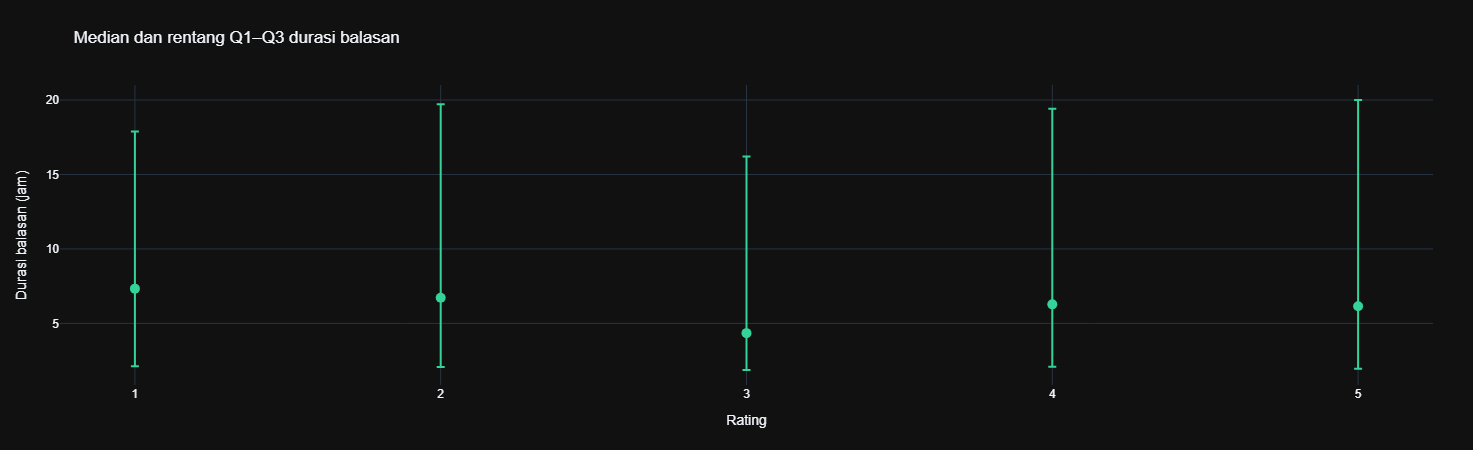

Tersimpan: 08_reply_delay


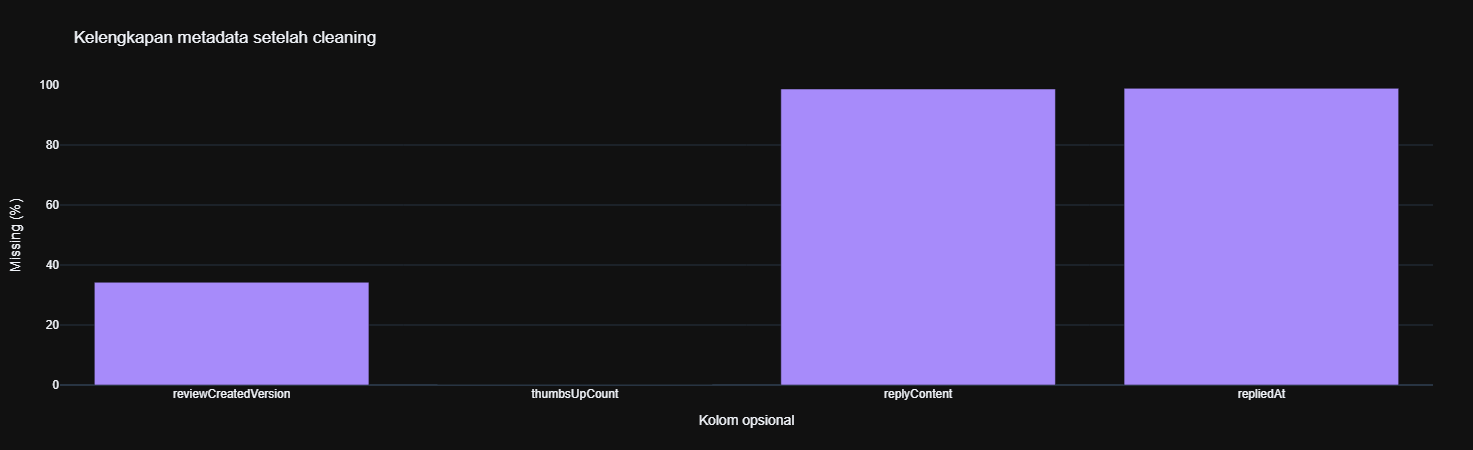

Tersimpan: 09_metadata_missing


In [10]:
figures = []
BLUE, RED, GREEN = '#38bdf8', '#fb7185', '#34d399'
def save_fig(fig, name, title, note):
    fig.update_layout(template='plotly_dark', title=title, height=450,
        font=dict(family='Arial'), margin=dict(l=60,r=40,t=85,b=65))
    fig.write_html(FIGURES / f'{name}.html', include_plotlyjs=True, full_html=True,
                   config={'responsive': True, 'displaylogo': False})
    figures.append({'name': name, 'title':title, 'note':note, 'figure':fig})
    if SHOW_INLINE:
        # MIME Plotly menyimpan data grafik saja, tanpa menyalin Plotly.js ke setiap output.
        fig.show(renderer='plotly_mimetype', config={'responsive':True,'displaylogo':False})
    print('Tersimpan:', name)
def empty_figure(message):
    fig = go.Figure()
    fig.add_annotation(text=message, x=0.5,y=0.5,xref='paper',yref='paper',showarrow=False)
    return fig

# 1: volume bulanan
fig=go.Figure(go.Bar(x=monthly['month'].to_list(), y=monthly['n'].to_list(), marker_color=BLUE,
    hovertemplate='Bulan %{x|%Y-%m}<br>Ulasan %{y:,}<extra></extra>'))
fig.update_layout(xaxis_title='Bulan sumber', yaxis_title='Jumlah ulasan')
save_fig(fig,'01_monthly_volume','Volume ulasan per bulan','Bulan pertama/terakhir dapat parsial; bulan kosong memiliki volume nol.')

# 2: rating dan persentase rendah, sumbu berbeda dengan label eksplisit
fig=make_subplots(specs=[[{'secondary_y':True}]])
fig.add_trace(go.Scatter(x=monthly['month'].to_list(),y=monthly['avg_score'].to_list(),
    name='Rating rata-rata',mode='lines+markers',line_color=BLUE,connectgaps=False),secondary_y=False)
fig.add_trace(go.Scatter(x=monthly['month'].to_list(),y=monthly['low_pct'].to_list(),
    name='Rating 1–2 (%)',mode='lines',line_color=RED,connectgaps=False),secondary_y=True)
fig.update_yaxes(title_text='Rating rata-rata (1–5)',range=[1,5],secondary_y=False)
fig.update_yaxes(title_text='Rating rendah (%)',range=[0,100],secondary_y=True)
fig.update_xaxes(title_text='Bulan sumber')
save_fig(fig,'02_monthly_rating','Rating dan proporsi ulasan rendah','Dua sumbu memakai satuan berbeda. Bulan tanpa review tidak memiliki nilai rating.')

# 3: distribusi rating
fig=go.Figure(go.Bar(x=ratings['score'].to_list(),y=ratings['n'].to_list(),customdata=ratings['pct'].to_list(),
 marker_color=[RED,RED,'#fbbf24',GREEN,GREEN],hovertemplate='Rating %{x}<br>Ulasan %{y:,}<br>%{customdata:.2f}%<extra></extra>'))
fig.update_layout(xaxis=dict(title='Rating',tickmode='linear',dtick=1),yaxis_title='Jumlah ulasan')
save_fig(fig,'03_rating_distribution','Distribusi rating 1–5','Denominator persentase adalah seluruh ulasan valid unik.')

# 4: komposisi bulanan
fig=go.Figure()
for category,color in [('Rendah (1–2)',RED),('Sedang (3)','#fbbf24'),('Tinggi (4–5)',GREEN)]:
    counts={str(d['month']):d['n'] for d in monthly_mix.filter(pl.col('category')==category).to_dicts()}
    percentages=[None if n==0 else 100*counts.get(str(m),0)/n for m,n in zip(monthly['month'],monthly['n'])]
    fig.add_trace(go.Bar(x=monthly['month'].to_list(),y=percentages,name=category,marker_color=color,
        hovertemplate='%{x|%Y-%m}<br>%{y:.2f}%<extra>'+category+'</extra>'))
fig.update_layout(barmode='stack',xaxis_title='Bulan sumber',yaxis=dict(title='Proporsi ulasan (%)',range=[0,100]))
save_fig(fig,'04_monthly_mix','Komposisi rating per bulan','Jumlah proporsi per bulan terisi adalah 100%; bulan kosong tidak diimputasi.')

# 5: hari/jam
counts={(d['weekday'],d['hour']):d['n'] for d in weekday_hour.to_dicts()}
fig=go.Figure(go.Heatmap(x=list(range(24)),y=['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu'],
 z=[[counts.get((day,hour),0) for hour in range(24)] for day in range(1,8)],colorscale='Blues',
 hovertemplate='%{y}, jam %{x}:00<br>Ulasan %{z:,}<extra></extra>',colorbar_title='Ulasan'))
fig.update_layout(xaxis=dict(title='Jam sumber (zona belum diverifikasi)',dtick=1),yaxis_title='Hari')
save_fig(fig,'05_weekday_hour','Pola ulasan menurut hari dan jam','Jumlah total per slot sepanjang periode; bukan tingkat aktivitas seluruh pemain dan bukan otomatis WIB.')

# 6: versi
if versions.height:
    data=versions.sort('avg_score')
    fig=go.Figure(go.Bar(y=data['version'].to_list(),x=data['avg_score'].to_list(),orientation='h',marker_color=BLUE,
      customdata=list(zip(data['n'].to_list(),data['low_pct'].to_list())),
      hovertemplate='Versi %{y}<br>Rating %{x:.2f}<br>n=%{customdata[0]:,}<br>Rating rendah %{customdata[1]:.2f}%<extra></extra>'))
    fig.update_layout(xaxis=dict(title='Rating rata-rata',range=[0,5]),yaxis=dict(title='Versi saat ulasan',type='category'))
else: fig=empty_figure(f'Tidak ada versi dengan minimal {MIN_VERSION_REVIEWS} ulasan.')
save_fig(fig,'06_version_rating','Rating menurut versi game',f'Maksimal 15 versi terbanyak dengan n≥{MIN_VERSION_REVIEWS}; perbedaan bukan bukti efek patch karena waktu/pengguna dapat berbeda.')

# 7: balasan per score
fig=go.Figure(go.Bar(x=reply_by_score['score'].to_list(),y=reply_by_score['reply_pct'].to_list(),marker_color=GREEN,
 customdata=list(zip(reply_by_score['n'].to_list(),reply_by_score['reply_n'].to_list())),
 hovertemplate='Rating %{x}<br>Balasan %{y:.2f}%<br>Total %{customdata[0]:,}<br>Dibalas %{customdata[1]:,}<extra></extra>'))
fig.update_layout(xaxis=dict(title='Rating',dtick=1),yaxis=dict(title='Balasan tersedia (%)',range=[0,100]))
save_fig(fig,'07_reply_rate','Ketersediaan balasan menurut rating','Denominator adalah jumlah ulasan pada masing-masing rating; snapshot bukan riwayat balasan lengkap.')

# 8: median dan interval kuartil, tanpa mengambil review mentah
if delay.height:
    fig=go.Figure(go.Scatter(x=delay['score'].to_list(),y=delay['median'].to_list(),mode='markers',
        marker=dict(size=10,color=GREEN),
        error_y=dict(type='data',symmetric=False,
            array=[d['q3']-d['median'] for d in delay.to_dicts()],
            arrayminus=[d['median']-d['q1'] for d in delay.to_dicts()]),
        customdata=[[d['n'],d['q1'],d['q3']] for d in delay.to_dicts()],
        hovertemplate='Rating %{x}<br>Median %{y:.2f} jam<br>Q1 %{customdata[1]:.2f}<br>Q3 %{customdata[2]:.2f}<br>n=%{customdata[0]:,}<extra></extra>'))
    fig.update_layout(yaxis_title='Durasi balasan (jam)',xaxis=dict(title='Rating',dtick=1))
else: fig=empty_figure('Tidak ada ulasan dengan balasan dan durasi tanggal valid.')
save_fig(fig,'08_reply_delay','Median dan rentang Q1–Q3 durasi balasan','Titik menunjukkan median dan garis menunjukkan Q1–Q3, bukan confidence interval. Hanya balasan bertanggal valid, tidak termasuk yang belum dibalas.')

# 9: null metadata
fig=go.Figure(go.Bar(x=missing['column'].to_list(),y=missing['null_pct'].to_list(),marker_color='#a78bfa',
 customdata=missing['null_n'].to_list(),hovertemplate='%{x}<br>Null %{y:.2f}%<br>n=%{customdata:,}<extra></extra>'))
fig.update_layout(xaxis_title='Kolom opsional',yaxis=dict(title='Missing (%)',range=[0,100]))
save_fig(fig,'09_metadata_missing','Kelengkapan metadata setelah cleaning','Missing bersifat berbeda: tidak ada balasan pada snapshot tidak sama dengan error input.')
assert len(figures)>=6

## 4. Insight berbasis angka dan analisis tren
Insight ditulis otomatis dengan denominator dan keterbatasan. Perubahan rating dibandingkan hanya pada bulan tengah (bukan bulan batas) dengan minimal 30 ulasan. Jika tidak cukup bulan/metadata, bagian itu menyatakan tidak cukup data; tidak menggantinya dengan kesimpulan rekaan.

In [11]:
insights=[]
n=stats['n']
insights.append(f"Rating rata-rata {stats['avg_score']:.3f}/5 pada {n:,} ulasan valid unik, periode {stats['start_date']} sampai {stats['end_date']}. Ini menggambarkan review teramati, bukan seluruh pemain.")
mode=ratings.sort(['n','score'],descending=[True,False]).row(0,named=True)
insights.append(f"Rating paling sering adalah {mode['score']} bintang: {mode['n']:,} ulasan ({mode['pct']:.2f}% dari {n:,}). Jika seri, rating lebih kecil dipilih sebagai laporan tunggal; distribusi lengkap ada pada tabel ratings.")
insights.append(f"Rating rendah (1–2) mencapai {stats['low_count']:,}/{n:,} ({stats['low_count']/n*100:.2f}%). Kategori ini adalah definisi rating rendah, bukan label sentimen NLP.")
peak=monthly.sort(['n','month'],descending=[True,False]).row(0,named=True)
insights.append(f"Bulan dengan ulasan terbanyak adalah {peak['month']}: {peak['n']:,} ({peak['n']/n*100:.2f}% dari semua review). Volume ini tidak sama dengan jumlah pemain aktif; bulan batas dapat parsial.")
insights.append(f"Balasan pengembang tersedia pada {stats['reply_count']:,}/{n:,} ulasan ({stats['reply_count']/n*100:.2f}%). Review tanpa balasan pada snapshot tidak membuktikan tidak pernah dibalas.")
insights.append(f"Median panjang review adalah {stats['median_content_length']:.1f} karakter Unicode. Nilai ini termasuk emoji dan spasi internal, serta tidak mengukur kualitas argumen pengguna.")
if stats['median_reply_hours'] is not None:
    insights.append(f"Median durasi balasan {stats['median_reply_hours']:.2f} jam, berdasarkan {stats['delay_n']:,} review dengan balasan dan tanggal valid (bukan semua {stats['reply_count']:,} review yang memiliki balasan). Seleksi ini dapat bias dan zona waktu perlu diverifikasi.")
else: insights.append('Durasi balasan tidak dapat diringkas karena tidak ada balasan dengan tanggal valid; hindari klaim kecepatan respons.')

interior=monthly.filter((pl.col('month')>monthly['month'][0]) &
    (pl.col('month')<monthly['month'][-1]) & (pl.col('n')>=MIN_MONTH_REVIEWS))
trend={'eligible_months':interior.height,'min_n':MIN_MONTH_REVIEWS}
if interior.height>=2:
    a,b=interior.row(0,named=True),interior.row(-1,named=True)
    diff=b['avg_score']-a['avg_score']
    trend.update({'first_month':str(a['month']),'last_month':str(b['month']),'rating_difference':diff})
    insights.append(f"Pada bulan tengah dengan n≥{MIN_MONTH_REVIEWS}, rating rata-rata berubah dari {a['avg_score']:.3f} ({a['month']}, n={a['n']:,}) ke {b['avg_score']:.3f} ({b['month']}, n={b['n']:,}), selisih {diff:+.3f} poin. Perbandingan dua titik bukan uji signifikansi atau bukti tren monoton.")
else: insights.append(f'Perbandingan rating antarbulan tengah belum dapat dibuat: hanya {interior.height} bulan memenuhi n≥{MIN_MONTH_REVIEWS} setelah bulan batas dikeluarkan.')
for i,t in enumerate(insights,1): print(f'{i}. {t}\n')
assert len(insights)>=5

1. Rating rata-rata 3.777/5 pada 10,448,835 ulasan valid unik, periode 2016-09-24 10:10:08 sampai 2026-09-27 07:20:57. Ini menggambarkan review teramati, bukan seluruh pemain.

2. Rating paling sering adalah 5 bintang: 6,309,889 ulasan (60.39% dari 10,448,835). Jika seri, rating lebih kecil dipilih sebagai laporan tunggal; distribusi lengkap ada pada tabel ratings.

3. Rating rendah (1–2) mencapai 2,833,547/10,448,835 (27.12%). Kategori ini adalah definisi rating rendah, bukan label sentimen NLP.

4. Bulan dengan ulasan terbanyak adalah 2020-07-01: 282,931 (2.71% dari semua review). Volume ini tidak sama dengan jumlah pemain aktif; bulan batas dapat parsial.

5. Balasan pengembang tersedia pada 138,739/10,448,835 ulasan (1.33%). Review tanpa balasan pada snapshot tidak membuktikan tidak pernah dibalas.

6. Median panjang review adalah 23.0 karakter Unicode. Nilai ini termasuk emoji dan spasi internal, serta tidak mengukur kualitas argumen pengguna.

7. Median durasi balasan 6.86 jam, b

## 5. Dashboard offline, laporan, dan catatan reproduksi
Dashboard ditulis sebagai satu HTML; data sumbernya hanya tabel agregat. Buka `output/milestone3/dashboard.html` dengan browser. Setiap HTML grafik juga dapat dibuka sendiri.
Folder output lama dengan nama sama ditimpa saat eksekusi ulang. Jangan menyatakan selesai sebelum semua cell dan assertions lulus pada CSV/Parquet asli.

In [12]:
import html
parts=['<!doctype html><html lang="id"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">',
 '<title>Mobile Legends — Milestone 3</title><style>body{margin:0;background:#0b1220;color:#e2e8f0;font:16px Arial}main{max-width:1280px;margin:auto;padding:28px}section{background:#111c30;border:1px solid #253651;border-radius:16px;padding:18px;margin:22px 0}p,li{line-height:1.6}h1{color:#38bdf8}.note{color:#a8b8ce}</style></head><body><main>',
 '<h1>Mobile Legends · Review Analytics</h1>',
 f'<p>{n:,} ulasan valid unik · Rating {stats["avg_score"]:.3f}/5 · {html.escape(str(stats["start_date"]))} — {html.escape(str(stats["end_date"]))}</p>',
 '<p class="note">Analisis review snapshot; tidak mewakili semua pemain. Waktu sumber bukan otomatis WIB. Bulan batas dapat parsial.</p>',
 '<section><h2>Insight</h2><ol>'+''.join('<li>'+html.escape(t)+'</li>' for t in insights)+'</ol></section>']
for i,item in enumerate(figures):
    parts.append('<section><h2>'+html.escape(item['title'])+'</h2><p class="note">'+html.escape(item['note'])+'</p>')
    parts.append(item['figure'].to_html(full_html=False,include_plotlyjs=True if i==0 else False,
        config={'responsive':True,'displaylogo':False}))
    parts.append('</section>')
parts.append('</main></body></html>')
(OUT/'dashboard.html').write_text(''.join(parts),encoding='utf-8')
report={'generated_at_utc':datetime.now(timezone.utc).isoformat(),'input':CLEAN.name,
    'input_bytes':CLEAN.stat().st_size,'validation':validation,'stats':stats,
    'min_version_reviews':MIN_VERSION_REVIEWS,'min_month_reviews':MIN_MONTH_REVIEWS,
    'trend':trend,'insights':insights,'figures':[{'name':x['name'],'title':x['title'],'note':x['note']} for x in figures],
    'versions':{'python':platform.python_version(),'duckdb':duckdb.__version__,'polars':pl.__version__,'plotly':plotly.__version__},
    'elapsed_seconds':round(time.perf_counter()-STARTED,2)}
(OUT/'eda_report.json').write_text(json.dumps(report,default=str,ensure_ascii=False,indent=2),encoding='utf-8')
summary='# Milestone 3 — EDA & Insight\n\n'+ '\n\n'.join(f'{i}. {s}' for i,s in enumerate(insights,1))
summary+='\n\n## Validasi dan keterbatasan\n\nInput memiliki ID unik, rating 1–5, content dan tanggal valid; jumlah agregat cocok dengan jumlah ulasan. Tidak ada uji kausal, filter negara, atau verifikasi zona waktu otomatis. Periksa pengaruh karantina dan duplikasi Milestone 2 sebelum menarik kesimpulan. Grafik versi membutuhkan dukungan sampel minimum.\n\n## AI Disclosure Statement\n\nAlat: ChatGPT/Codex. Bantuan: penyusunan SQL agregasi, visualisasi Plotly, dan template insight. Eksekusi teknis ini selesai dengan assertions lulus. Mahasiswa perlu menuliskan verifikasi dan pemahaman yang benar-benar dilakukan; jangan mengklaim telah memahami tanpa meninjau kode/output.\n'
(OUT/'milestone3_results.md').write_text(summary,encoding='utf-8')
con.close()
print('Selesai. Dashboard:', OUT/'dashboard.html')
print('Simpan notebook dengan output asli, periksa laporan, dan lengkapi disclosure sebelum commit.')

Selesai. Dashboard: /home/jovyan/work/output/milestone3/dashboard.html
Simpan notebook dengan output asli, periksa laporan, dan lengkapi disclosure sebelum commit.


## Checklist pengumpulan Milestone 3
- Jalankan semua cell pada Parquet asli hasil cleaning; simpan notebook dengan output nyata.
- Periksa tabel, hover grafik, dan insight. Jelaskan keterbatasan snapshot, zona waktu, serta bulan parsial.
- Dataset dengan kurang dari enam grafik yang memiliki data perlu ditinjau; grafik tanpa metadata bukan bukti analisis tambahan.
- HTML dashboard dan grafik dihasilkan lokal; jangan commit CSV/Parquet atau folder spill.
- Tambahkan dokumentasi hasil aktual dan AI Disclosure Statement pada README utama.
- Gunakan commit Milestone 3 yang mencerminkan hasil benar-benar sudah diverifikasi.

Referensi: [DuckDB tuning](https://duckdb.org/docs/stable/guides/performance/how_to_tune_workloads), [Plotly HTML offline](https://plotly.com/python/interactive-html-export/).